# Wind speed and network generation
This notebook illustrates the creation of synthetic data for networks, offers,
bids, and wind scenarios.
These are used by Model 2 in the dissertation.

In particular, it is used to produce a summary picture at the end of the
notebook.
It is for the generation of this image that this notebook has been included.

Note that this *notebook* is not actually used in the testing of Model 2, for
which the synthetic data generation is separated into the file 
`wind_data_module.py`.

In [1]:
# IMPORTS
# -------
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import networkx as nx

from sklearn.linear_model import LinearRegression

from shapely.geometry import Point

In [2]:
# PARAMETERS
# ----------

# Data files
# ----------
shapefile_path = "geodata/gb.shp"

# Wind parameters
# ---------------
L_decay = 723 # (km). Length scale for exponential decay of correlation w/distance.
cutin_speed = 3 # (m/s) Speed at which wind power is available
rated_speed = 13 # (m/s) Speed at which wind power operates at rated capacity
cutout_speed = 25 # (m/s) Speed at which wind power unavailable

capacity_options = [100, 200, 400] # (MW) Rated capacities of wind projects

# Network parameters
# ------------------
nb_T1_buses = 10 # number of buses for demand and/or traditional generation
nb_T2_buses = 3 # number of wind power projects

p1 = 10 # PERCENTAGE of extra links for EXISTING network (over and above MST).
p2 = 20 # PERCENTAGE of links to consider opening (over and above second MST).
p3 = 50 # PERCENTAGE of T1 buses which have existing generation.

cost_per_km = 120_000 # (EUR) Cost per km of transmission line.

# Offer parameters
# ----------------
nb_scenarios = 5

gen_cap_low = 150 # (MW) - minimum capacity of a generating unit
gen_cap_high = 600 # (Mw) - maximum capacity of a generating unit

p4 = 2  # PERCENTAGE of thermal unit offers which are 0.
b_offer = 59.6 # Price of the first MWh
m_offer = 0.0394 # Increase in price for each additional MWh
block_premium = 0.1 # PROPORTION by which to increase the price of the next block

# Bid parameters
# --------------
demand_low = 40 # (MW) - lowest possible total demand by a customer (base case)
demand_high = 240 # (MW) - highest possible total demand by a customer (base case)

bid_price_low = 110 # (EUR/MWh)
bid_price_high = 120 # (EUR/MWh)


# Miscellaneous parameters
# ------------------------
IC_scale = 1000 # factor by which to multiply Investment Cost from csv



In [3]:
# RANDOM NUMBER GENERATION
rng = np.random.default_rng()

## Wind speed calculations

The aim in this part is to build a suitable model for windspeed based on the UK
data. The model will be a very great simplification but should capture something
about the UK averages as well as the correlation between nearby locations.

In [4]:
# Import wind speed data from .csv:
wind_speed_df = pd.read_csv("wind_data.csv", index_col="OBJECTID")

# Access the (x,y) coordinates of each wind measurement point:
x = wind_speed_df['x_coord']
y = wind_speed_df['y_coord']

# Access the spring, summer, autumn, and winter temperatures (by location):
v_spr = wind_speed_df['windspeed spring baseline median']
v_sum = wind_speed_df['windspeed summer baseline median']
v_aut = wind_speed_df['windspeed autumn baseline median']
v_win = wind_speed_df['windspeed winter baseline median']

# Calculate the average windspeed at each location:
v_avg = wind_speed_df[['windspeed spring baseline median', 
                       'windspeed summer baseline median', 
                       'windspeed autumn baseline median', 
                       'windspeed winter baseline median']].mean(axis=1)

In [5]:
def regression_sklearn(y, x1, x2):
    '''Get the intercept and coefficients of the linear regression of y onto two
    explanatory variables x1 and x2.'''
    
    y = np.asarray(y)
    X = np.column_stack((x1, x2))  # No need to add intercept manually

    model = LinearRegression()
    model.fit(X, y)

    intercept = model.intercept_
    coefficients = model.coef_

    return intercept, coefficients

In [6]:
# Calculate coeffs for best linear approximation for average windspeed at (x,y):
intercept, coefficients = regression_sklearn(v_avg, x, y)

In [7]:
intercept, coefficients

(4.106034866084783, array([-9.53850467e-07,  1.02939352e-06]))

In [8]:
# Formula for the average windspeed at point (x,y); based on linear model:
def avg_windspeed(x,y):
    return intercept + coefficients[0]*x + coefficients[1]*y

## Network generation

We now want to create a network with demand and traditional generation located
at buses on land; wind energy projects can be located anywhere within the
bounding box for the wind data points.

In [9]:
# LOCATIONS FOR WIND POWER PROJECTS
# ---------------------------------

# Create a box around the locations for which windspeed data was provided:
x_min = np.min(x)
x_max = np.max(x)
y_min = np.min(y)
y_max = np.max(y)

# Wind power projects can be located anywhere within this box:
T2_x = rng.uniform(low = x_min, high = x_max, size = nb_T2_buses)
T2_y = rng.uniform(low = y_min, high = y_max, size = nb_T2_buses)

In [10]:
# LOCATIONS FOR DEMAND/TRADITIONAL GENERATION BUSES
# -------------------------------------------------

# Load the UK data
uk = gpd.read_file(shapefile_path)
uk = uk.to_crs(epsg=27700)

# Create bounding box for the UK shapefile:
minx, miny, maxx, maxy = uk.total_bounds

In [11]:
minx, maxx

(-296663.1519227418, 656135.7314214569)

In [12]:
def generate_random_point():
    '''Create a point inside the UK.'''
    for _ in range(10_000): # Attempt at most 10_000 times...
        
        # Generate a point in the bounding box:
        x = rng.uniform(minx, maxx)
        y = rng.uniform(miny, maxy)
        point = Point(x, y)
        
        # Check if it's inside the UK boundary:
        if uk.contains(point).any():
            return point
    raise ValueError("Failed to generate a valid point within UK.")

In [13]:
# Create the locations for the buses with demand and/or traditional generation:
points = [generate_random_point() for _ in range(nb_T1_buses)]

# Store their (x,y) positions:
T1_x = [P.x for P in points]
T1_y = [P.y for P in points]

In [14]:
# Create a DataFrame to store the information about the buses.
# N.B. the buses are marked either T1 (demand/traditional generation) or T2 (
# wind generation locations).

# Create T1 DataFrame:
T1_df = pd.DataFrame(
    {
        "bus_type": "T1",
        "x": T1_x,
        "y": T1_y
    }
)
# T1_df['bus_id'] = "T1_" + T1_df.index.astype(str)
T1_df['Bus'] = "T1_" + (T1_df.index+1).astype(str)
T1_df = T1_df.set_index('Bus')

# Create T2 DataFrame:
T2_df = pd.DataFrame(
    {
        "bus_type": "T2",
        "x": T2_x,
        "y": T2_y
    }
)
# T2_df['bus_id'] = "T2_" + T2_df.index.astype(str)
T2_df['Bus'] = "T2_" + (T2_df.index+1).astype(str)
T2_df = T2_df.set_index('Bus')

# Bring the T1 and T2 DataFrames together as one:
buses_df = pd.concat([T1_df, T2_df])

In [15]:
# Graph for the transmission network
# ----------------------------------
# The graph consists of T1 buses and the edges between them are the distances.

# Extract coordinates
coords = T1_df[['x', 'y']].values
T1_bus_ids = T1_df.index.to_numpy()

# Compute full pairwise distance matrix
dist_matrix = sp.spatial.distance.cdist(coords, coords)

G = nx.Graph()
n = len(T1_bus_ids)

ebunch = [
    (T1_bus_ids[i], T1_bus_ids[j], dist_matrix[i, j])
    for i in range(n) for j in range(n) if i < j
]

G.add_weighted_edges_from(ebunch)

In [16]:
# Create a plausible transmission network based on the minimum spanning tree:
T = nx.minimum_spanning_tree(G)

# Add some extra edges (the shortest p1% of links NOT already in T):
candidates = [e for e in G.edges() if not T.has_edge(*e)]
nb_to_add = int(np.floor(len(candidates)*(p1/100)))
for u,v in sorted(candidates, key=lambda e: G[e[0]][e[1]]['weight'])[:nb_to_add]:
    T.add_edge(u, v, weight=G[u][v]['weight'])

In [17]:
# PLAUSIBLE TRANSMISSION EXTENSIONS
# ---------------------------------

# Second spanning tree:
# ---------------------
# Create complement of the actual minimum spanning tree (TC = G\T):
G_edges = set(G.edges())
T_edges = set(T.edges())
TC_edges = G_edges - T_edges
TC = nx.Graph()
ebunch = [(u, v, G[u][v]['weight']) for u,v in TC_edges]
TC.add_weighted_edges_from(ebunch)

# Create the minimum spanning of TC = G\T:
TCT = nx.minimum_spanning_tree(TC)

# Add some extra edges (the shortest p2% of links NOT already in TCT):
candidates = [e for e in G.edges() if (not TCT.has_edge(*e) and not T.has_edge(*e))]
nb_to_add = int(np.floor(len(candidates)*(p2/100)))
for u,v in sorted(candidates, key=lambda e: G[e[0]][e[1]]['weight'])[:nb_to_add]:
    TCT.add_edge(u, v, weight=G[u][v]['weight'])

In [18]:
# Closest T1 bus to each T2 bus:
# ------------------------------
T2_coords = T2_df[['x', 'y']].values

# Compute distance matrix between T2 and T1 buses
dist_matrix_T2_T1 = sp.spatial.distance.cdist(T2_coords, coords)
# N.B. Rows are T2 buses, columns are T1 buses

# In a dictionary, store the closest T1 bus for each T2 bus:
closest_connection = {}
closest_distance = {}
for i, T2 in enumerate(T2_coords):
    T2_bus_id = T2_df.index[i]
    j = np.argmin(dist_matrix_T2_T1[i,:])
    T1_bus_id = T1_df.index[j]
    # print(f"Bus {T2_bus_id} is closest to {T1_bus_id}")
    # print("")
    closest_connection[T2_bus_id] = T1_bus_id
    closest_distance[T2_bus_id] = dist_matrix_T2_T1[i,j]

# Add the closest_connection dictionary as a column to the T2 DataFrame:
T2_df['closest_T1'] = T2_df.index.map(closest_connection)

I now need to be able to add the reactance, capacity, and investment cost data
to the lines of the network.

In [19]:
# The p.u. reactances in Garces et al. (2009) have mean 0.418 and variance 0.164
reactances = [0.4,0.38,0.60,0.20,0.68,0.20,0.40,0.31,0.30,0.59,0.20,0.48,0.63,0.30,0.61]
reactance_mean = np.mean(reactances)
reactance_std = np.std(reactances)

print(f"Mean: {reactance_mean}. \n s.d. : {reactance_std}")

lower, upper = np.min(reactances), np.max(reactances)
a, b = (lower - reactance_mean) / reactance_std, (upper - reactance_mean) / reactance_std
reactance_distn = sp.stats.truncnorm(a, b, loc=reactance_mean, scale=reactance_std)

print(f"lower: {lower}\n upper: {upper}")

Mean: 0.4186666666666667. 
 s.d. : 0.1635386464689276
lower: 0.2
 upper: 0.68


In [20]:
# The capacities (in MW) have mean 92.3 and variance 11.1.
cap = [100,100,80,100,70,100,100,100,100,82,100,100,75,100,78]
cap_mean = np.mean(cap)
cap_std = np.std(cap)

print(f"Mean: {cap_mean}. \n s.d. : {cap_std}")

lower, upper = np.min(cap), np.max(cap)
a, b = (lower - cap_mean) / cap_std, (upper - cap_mean) / cap_std
cap_distn = sp.stats.truncnorm(a, b, loc=cap_mean, scale=cap_std)

Mean: 92.33333333333333. 
 s.d. : 11.10955544665142


In [21]:
lower, upper

(70, 100)

In [22]:
dist = [G[e[0]][e[1]]['weight']/1000 for e in T.edges()] # distance in km
from_u = [u for u, _ in T.edges()]
to_v = [v for _, v in T.edges()]

# Construct a DataFrame to contain the existing lines' data:
existing_lines_df = pd.DataFrame(
    {
        'From': from_u,
        'To': to_v,
        'Distance': dist
    }
)

# Add the relevant data to the existing_lines_df:
existing_lines_df['Investment_Cost'] = (existing_lines_df['Distance'] * cost_per_km) / IC_scale
line_capacities = list(cap_distn.rvs(size = len(existing_lines_df)))
existing_lines_df['Capacity'] = line_capacities
line_reactances = list(reactance_distn.rvs(size = len(existing_lines_df)))
existing_lines_df['Reactance'] = line_reactances
existing_lines_df['Existing'] = 1
existing_lines_df['Line_Copy'] = 1
# N.B. Line capacities are the same for all lines in the same corridor.

In [23]:
# Create copies of the existing lines as potential expansions:
dist += dist
from_u += from_u
to_v += to_v

el_copy_df = pd.DataFrame(
    {
        'From': from_u,
        'To': to_v,
        'Distance': dist,
        'Line_Copy': len(existing_lines_df)*[2] + len(existing_lines_df)*[3] 
    }
)

# Add the relevant data to the existing_lines_df:
el_copy_df['Investment_Cost'] = (el_copy_df['Distance'] * cost_per_km) / IC_scale
el_copy_df['Capacity'] = 2*line_capacities # line_capacities is a list
el_copy_df['Reactance'] = 2*line_reactances # likewise, this is a list
el_copy_df['Existing'] = 0

# Create a single DataFrame for the existing corridors:
existing_corridors_df = pd.concat([existing_lines_df, el_copy_df])

In [24]:
# Now create transmission line expansions for the NEW corridors:
# N.B. This does not yet include the connections for wind projects.
dist = 3*[G[e[0]][e[1]]['weight']/1000 for e in TCT.edges()] # distance in km
from_u = 3*[u for u, _ in TCT.edges()]
to_v = 3*[v for _, v in TCT.edges()]

# Construct a DataFrame to contain the existing lines' data:
prospective_lines_df = pd.DataFrame(
    {
        'From': from_u,
        'To': to_v,
        'Distance': dist
    }
)

# Add the relevant data to the prospective_lines_df:
prospective_lines_df['Investment_Cost'] = (prospective_lines_df['Distance'] * cost_per_km) / IC_scale
line_capacities = list(cap_distn.rvs(size = len(TCT.edges())))
prospective_lines_df['Capacity'] = 3*line_capacities
line_reactances = list(reactance_distn.rvs(size = len(TCT.edges())))
prospective_lines_df['Reactance'] = 3*line_reactances
prospective_lines_df['Existing'] = 0
prospective_lines_df['Line_Copy'] = len(TCT.edges())*[1] + len(TCT.edges())*[2] + len(TCT.edges())*[3]

In [25]:
# Finally create lines for the connections to the grid:
from_u = 3*[u for u,_ in closest_connection.items()]
to_v = 3*[v for _,v in closest_connection.items()]
dist = 3*[closest_distance[u]/1000 for u,_ in closest_connection.items()] # km

# Create a DataFrame to store the T2 to T1 connection lines:
connection_lines_df = pd.DataFrame(
    {
        'From': from_u,
        'To': to_v,
        'Distance': dist
    }
)

# Add the relevant data to the connection_lines_df:
# -------------------------------------------------
# Calculate investment cost (in EUR 000s) from connection distances:
connection_lines_df['Investment_Cost'] = (connection_lines_df['Distance'] * cost_per_km) / IC_scale

# Connection capacity commensurate with rated capacity:
line_capacities = nb_T2_buses * [capacity_options[1]]  

# Create capacities for ALL copies of ALL lines:
connection_lines_df['Capacity'] = 3*line_capacities

# Create reactances for ALL lines and ALL copies:
line_reactances = list(reactance_distn.rvs(size = nb_T2_buses))
connection_lines_df['Reactance'] = 3*line_reactances

# Ensure lines are not already present:
connection_lines_df['Existing'] = 0

# Label the line copies appropriately:
connection_lines_df['Line_Copy'] = nb_T2_buses*[1] + nb_T2_buses*[2] + nb_T2_buses*[3]
    

## Creating the offer data

In [26]:
# Quick look at the offer size and the price:

# x = np.array([60, 60+45, 60+45+45,
#      144, 144+108, 144+108+108,
#      240, 240+180, 240+180])

x = np.array([60, 60+45, 60+45+45,
     144, 144+108, 144+108+108,
     240, 240+180, 240+180+180])

# x = np.array([60, 45, 45,
#      144, 108, 108,
#      240, 180, 180])

y = [60, 65, 68,
     65, 68, 70,
     70, 75, 80]

coeffs = np.polyfit(x,y,1)

# b is the cost of the first MWh; slope is the increase in cost per MWh:
slope, b =  coeffs[0], coeffs[1]

In [27]:
# Generate the capacity of generators as something uniform between 150 MW and
# 600 MW:
G_plus = {k: np.floor(rng.binomial(1,p3/100)*rng.uniform(gen_cap_low,gen_cap_high)) for k in T1_bus_ids}

# Get the capacities which are non-zero:
G_plus_non_zero = {k: v for k,v in G_plus.items() if v > 0}

# s_i has keys which are generating units and values which are their buses:
s_i = {gen_id+1: bus_id for gen_id, bus_id in enumerate(G_plus_non_zero.keys())}

# Create GENERIC offer data first (not by scenario):
offer_data = pd.DataFrame(
    {
        "Generating_Unit": list(s_i.keys())
    }
)

offer_data['Bus'] = s_i.values()

offer_data = offer_data.merge(pd.DataFrame({'Block': [1, 2, 3]}), how='cross')
offer_data = offer_data.merge(pd.DataFrame({'Scenario': list(range(1, nb_scenarios+1))}), how='cross')

offer_data = offer_data.sort_values(by = ["Scenario","Generating_Unit","Block"])

In [28]:
def offer_size_fn(unit, block):
    if block == 1:
        return np.floor(0.4 * G_plus[s_i[unit]] * rng.binomial(1, 1-p4/100))
    else:
        return np.floor(0.3 * G_plus[s_i[unit]] * rng.binomial(1, 1-p4/100))

In [29]:
def offer_price_fn(offer_size, block):
    base_offer = b_offer + m_offer * offer_size
    if block == 1:
        return np.round(base_offer)
    else:
        return np.round(offer_price_fn(offer_size,1) * (1 + block_premium*(block-1)))

In [30]:
offer_data['Offer_Size'] = offer_data.apply(
    lambda row: offer_size_fn(row['Generating_Unit'], row['Block']), axis=1)

offer_data['Offer_Price'] = offer_data.apply(
    lambda row: offer_price_fn(row['Offer_Size'], row['Block']), axis=1)

offer_data = offer_data[['Scenario', 'Generating_Unit', 'Bus', 'Block', 'Offer_Size', 'Offer_Price']]

# offer_data.to_csv('sim_offer_data.csv', index=False)

## Creating the bid data

In [31]:
D_plus = {k: rng.uniform(demand_low, demand_high) for k in T1_bus_ids}

s_j = {cust_id+1: bus_id for cust_id, bus_id in enumerate(D_plus.keys())}

bid_data = pd.DataFrame(
    {
        "Customer": list(s_j.keys()),
        "Bus": T1_bus_ids
    }
)

bid_data = bid_data.merge(pd.DataFrame({'Block': [1, 2, 3]}), how='cross')
bid_data = bid_data.merge(pd.DataFrame({'Scenario': list(range(1, nb_scenarios+1))}), how='cross')

bid_data = bid_data.sort_values(by = ["Scenario","Customer","Block"])

In [32]:
def bid_size_fn(customer, block):
    if block == 1:
        return np.round(0.9 * D_plus[s_j[customer]])
    else:
        return np.floor(0.1 * D_plus[s_j[customer]])

In [33]:
bid_price = {k: rng.uniform(bid_price_low, bid_price_high) for k in T1_bus_ids}

In [34]:
def bid_price_fn(customer, block):
        return np.round((0.9)**(block-1) * bid_price[s_j[customer]])

In [35]:
bid_data['Bid_Size']= bid_data.apply(lambda row: bid_size_fn(row['Customer'], row['Block']), axis=1)
bid_data['Bid_Price'] = bid_data.apply(lambda row: bid_price_fn(row['Customer'], row['Block']), axis=1)

bid_data = bid_data[['Scenario', 'Customer', 'Bus', 'Block', 'Bid_Size', 'Bid_Price']]

# bid_data.to_csv('sim_bid_data.csv', index = False)

## Creating the wind power availability data

In [36]:
# CREATE SCENARIOS FOR WIND SPEED AT EACH LOCATION
# ------------------------------------------------
# Get the average windspeed at the location
T2_df['Average_Windspeed'] = avg_windspeed(T2_df['x'], T2_df['y'])

# Extract locations of T2 buses and measure in km NOT m:
locations = T2_df[['x','y']].to_numpy()/1000

# Calculate distances between T2 buses:
D = sp.spatial.distance_matrix(locations, locations)

# Calculate correlations coefficients for locational wind speeds:
R = np.exp(-D/L_decay)

# Generate one standard normal variable for each bus and scenario:
X = rng.normal(size=(nb_T2_buses,nb_scenarios))

# Induce the correlation between buses (correlated within each scenario):
L = np.linalg.cholesky(R)
Y = np.matmul(L,X)
# N.B. Y still contains one r.v. for each bus and scenario.

# Get the percentiles of each transformed r.v.:
U = sp.stats.norm.cdf(Y)

# Create RAYLEIGH r.v.s for each location
# ---------------------------------------
# This uses the percentile from U and the average wind speed for the location.

# Create scale parameters for the Rayleigh distribution:
scale_params = T2_df['Average_Windspeed'].to_numpy() * (2/np.sqrt(np.pi))
# N.B. This is because the scale parameter is mean * (2/sqrt(pi)).

# Create a grid, so it can be used for multiple scenarios:
scale_params = np.tile(scale_params,(nb_scenarios,1)).transpose()

# Create the wind speeds:
k = 2 # To create the Rayleigh distribution (Weibull special case)
V = sp.stats.weibull_min.ppf(U, c=k, scale=scale_params)

In [37]:
def P_max_px_fn(V, cutin_speed=cutin_speed, rated_speed=rated_speed, cutout_speed=cutout_speed):
    '''Calculates proportion of Rated_Capacity available, given wind speed.
    Args:
        V: np.array of wind speeds
        cutin_speed: wind turbine cut-in speed (typically 3 m/s)
        rated_speed: wind turbine rated speed (typically 13 m/s)
        cutout_speed: wind turbine cut-out speed (typically 25 m/s)
    Returns:
        result: np.array of proportions of Rated_Capacity available
    '''

    result = np.zeros_like(V, dtype=float)
    
    # Ramp region: between cut-in and rated
    ramp_mask = (V >= cutin_speed) & (V <= rated_speed)
    result[ramp_mask] = (V[ramp_mask] - cutin_speed) / (rated_speed - cutin_speed)
    
    # Flat region: between rated and cut-out
    flat_mask = (V > rated_speed) & (V <= cutout_speed)
    result[flat_mask] = 1
    
    return result


In [38]:
# Calculate the percentage of Rated_Capacity available by bus in each scenario:
P_max_px = P_max_px_fn(V)

# Each row is a bus, each column is a scenario:
P_max_px_df = pd.DataFrame(P_max_px, index=T2_df.index)
P_max_px_df.columns = pd.Index(range(1,P_max_px.shape[1]+1), name='Scenario')

# Use P_max_px_df to create a DataFrame with one row for each Bus | Scenario:
# The value is the proportion of Rated_Capacity available for that Bus-Scenario.
proportions_long = (
    P_max_px_df
    .rename_axis(index='Bus')
    .reset_index()
    .melt(id_vars='Bus', var_name='Scenario', value_name='Proportion')
)

# Store each wind power project at each bus with its capacity:
WPPs = pd.DataFrame(
    [(bus, f'{bus}_W{i}', cap) for bus in T2_df.index for i, cap in enumerate(capacity_options, start=1)],
    columns=['Bus', 'WPP', 'Rated_Capacity']
)

# Create the final DataFrame for the wind data
# --------------------------------------------
# Merge the WPPs data with the available proportions of Rated_Capacity:
out = proportions_long.merge(WPPs, on='Bus', how='inner')

# Use the scenario-based proportion factor to calculate offer size:
out['Offer_Size'] = np.round(out['Rated_Capacity'] * out['Proportion'])

# Tidy up the DataFrame:
out = out[['Scenario', 'WPP', 'Bus', 'Rated_Capacity', 'Offer_Size']]

# Export to csv:
# out.to_csv("sim_wind_data.csv", index=False)

## Plotting the wind and network

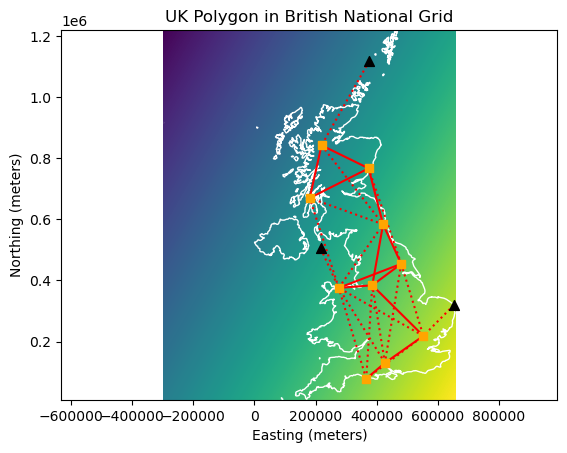

In [39]:
# Creating the wind speed background
def background_wind(x,y):
    return intercept + coefficients[0]*x + coefficients[1]*y

X = np.linspace(minx, maxx,2)
Y = np.linspace(miny, maxy,2)
Z = np.array([background_wind(x,y) for x in X for y in Y]).reshape(2,2)

fig, ax = plt.subplots()

ax.set_title("UK Polygon in British National Grid")
ax.set_xlabel("Easting (meters)")
ax.set_ylabel("Northing (meters)")
ax.axis("equal")  # Ensures correct aspect ratio

# # Wind over land:
# ax.scatter(x,y,s=1, c=v_pre, cmap="YlGnBu")

# Wind over whole grid:
ax.contourf(X,Y,Z,1000, zorder=1)

# Edge of the UK
uk.plot(ax=ax, edgecolor='white', facecolor="none", zorder =2)

# Min cost spanning tree (plus sprinkled edges):
for e in T.edges():
    x0 = buses_df.loc[[e[0]],'x']
    y0 = buses_df.loc[[e[0]],'y']
    x1 = buses_df.loc[[e[1]],'x']
    y1 = buses_df.loc[[e[1]],'y']

    ax.plot([x0,x1], [y0,y1], 'r-', zorder=3)

# Plausible transmission expansions:
for e in TCT.edges():
    x0 = buses_df.loc[[e[0]],'x']
    y0 = buses_df.loc[[e[0]],'y']
    x1 = buses_df.loc[[e[1]],'x']
    y1 = buses_df.loc[[e[1]],'y']

    ax.plot([x0,x1], [y0,y1], 'r:', zorder=3)

# Closest renewable to grid connections:
for k, v in closest_connection.items():
    x0 = buses_df.loc[k,'x']
    y0 = buses_df.loc[k,'y']
    x1 = buses_df.loc[v,'x']
    y1 = buses_df.loc[v,'y']

    ax.plot([x0,x1], [y0,y1], 'r:', zorder=3)

# Wind power project locations:
ax.scatter(T2_x, T2_y, s=50, c="black", marker="^", zorder=5)

# Other buses:
ax.scatter(T1_x, T1_y, s=30, c='orange', marker="s", zorder =4)

plt.show()